In [1]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_RfxCas13a_validation_cnn1.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_RfxCas13a_validation_cnn1.csv", index=False)


    Feature     Q1     Q3  Median Spearman Correlation
0   Pos37_A  0.625  0.764                        0.720
1   Pos37_C  0.132  0.652                        0.309
2   Pos38_A  0.086  0.530                        0.440
3   Pos38_U  0.075  0.318                        0.214
4   Pos39_C  0.216  0.595                        0.386
5   Pos41_C  0.132  0.703                        0.266
6   Pos42_A  0.112  0.390                        0.261
7   Pos42_U  0.111  0.421                        0.176
8   Pos43_U  0.225  0.430                        0.299
9   Pos44_A  0.139  0.543                        0.268
10  Pos44_U  0.178  0.500                        0.310
11  Pos45_U  0.030  0.602                        0.400
12  Pos46_U  0.396  0.655                        0.509
13  Pos47_U  0.548  0.711                        0.677
14  Pos48_U  0.488  0.612                        0.534
15  Pos49_U  0.427  0.635                        0.598
16  Pos50_G  0.007  0.158                        0.063
17  Pos50_

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_87189/98762204.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


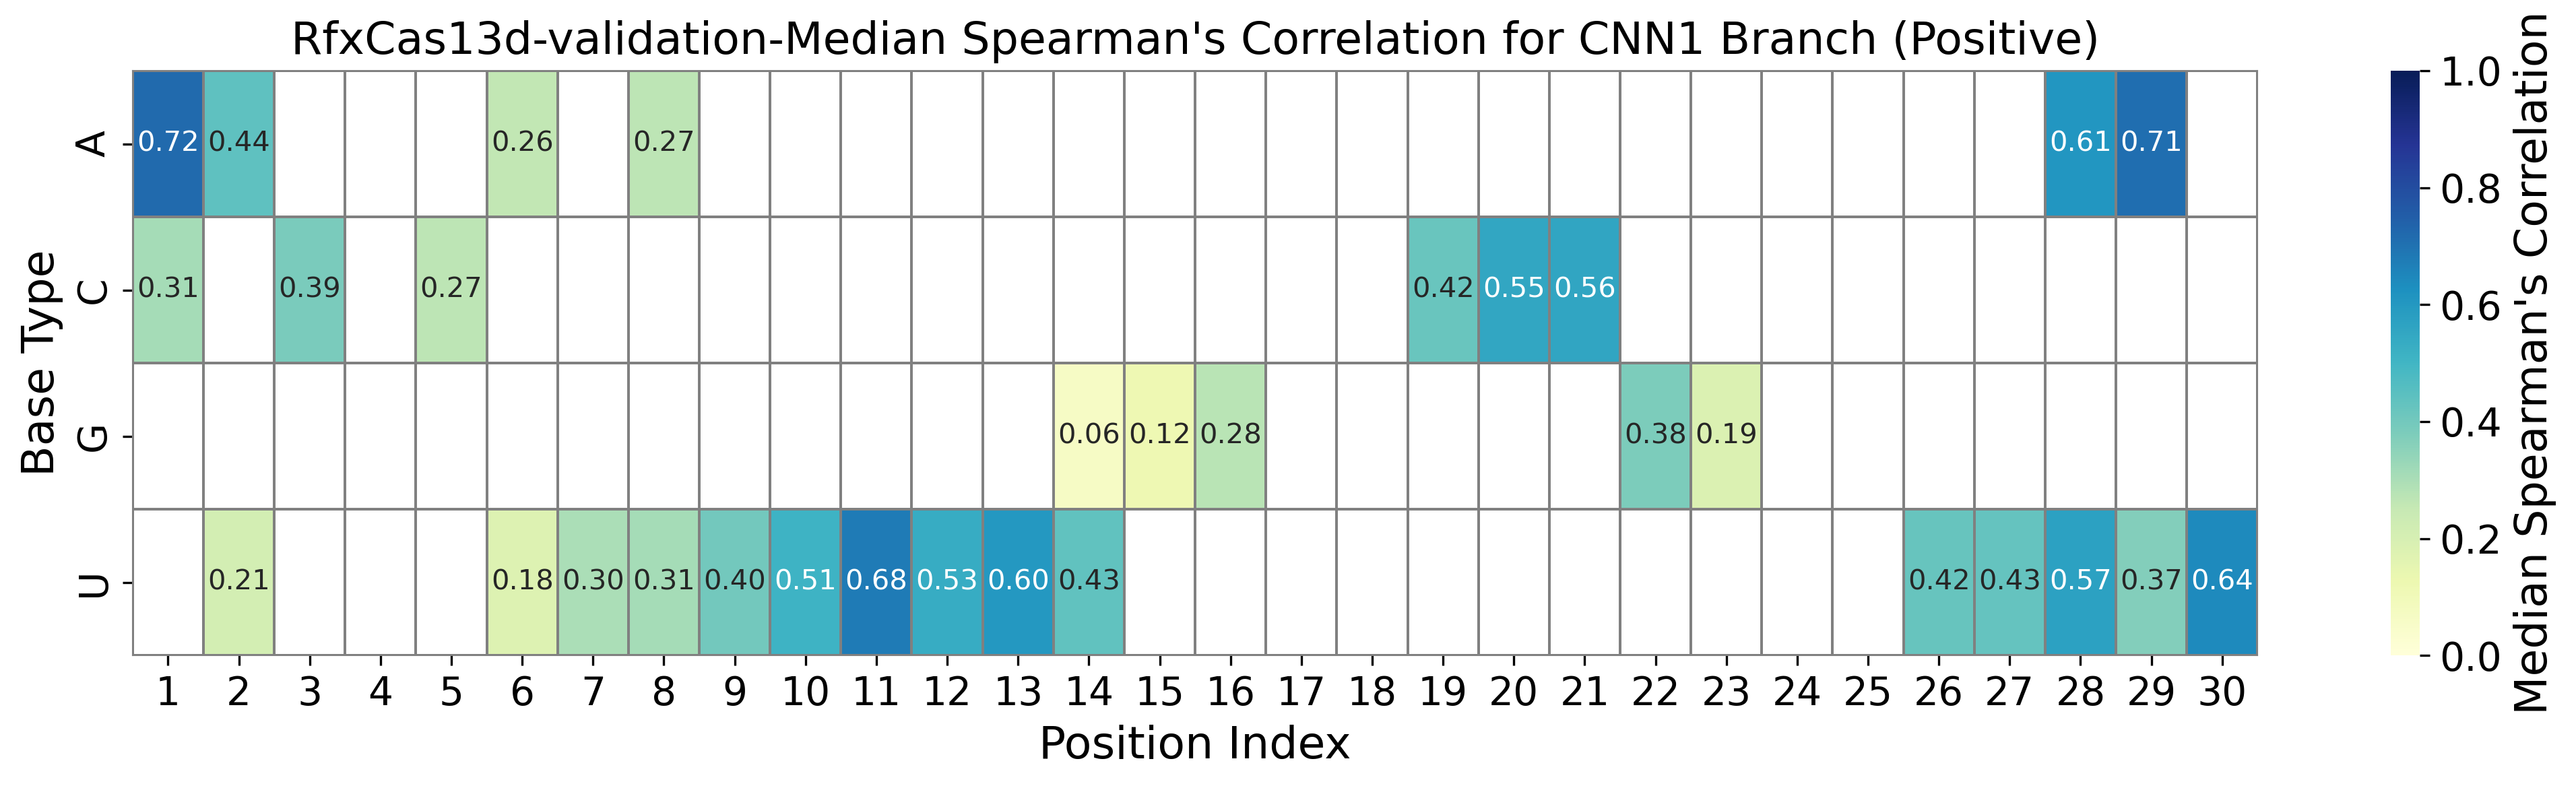

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load processed feature list
iqr_df = pd.read_csv("features_with_positive_IQR_RfxCas13a_validation_cnn1.csv")
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(\w)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# Pivot to heatmap format
heatmap_data = iqr_df.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Ensure all four base types are present, even if some rows are all NaN
base_order = ['A', 'C', 'G', 'U']
heatmap_data = heatmap_data.reindex(base_order)

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

mask = heatmap_data.isna()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=mask,
    ax=ax
)

# Force x-axis labels to start from 1
n_pos = heatmap_data.shape[1]
ax.set_xticks(np.arange(n_pos) + 0.5)
ax.set_xticklabels(range(1, n_pos + 1), fontsize=14)

# === Fix for missing bottom and right borders ===
# Turn on all spines (border lines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')


# Set custom font sizes
ax.set_xlabel("Position Index", fontsize=16)
ax.set_ylabel("Base Type", fontsize=16)
ax.set_title("RfxCas13d-validation-Median Spearman's Correlation for CNN1 Branch (Positive)", fontsize=16)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# === Adjust colorbar font sizes ===
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Colorbar tick labels
cbar.set_label("Median Spearman's Correlation", fontsize=16)  # Colorbar title

plt.tight_layout()
plt.show()
